***STEP 1.2 — EDA (Exploratory Data Analysis)***

**Analyze Class Distribution**  

Check imbalance → avoid biased model

In [1]:
import os            # file handling (paths, folders)

from PIL import Image  # alternative image loading

import matplotlib.pyplot as plt  # plots, image display

In [2]:
BASE_DIR = r'C:\Users\SAKTHI\Desktop\SMARTVISION\smartvision_dataset'
CLASSIFICATION_DIR = os.path.join(BASE_DIR, "classification")

In [3]:
splits = ["train", "val", "test"]


TRAIN dataset:
airplane: 70 images
bed: 70 images
bench: 70 images
bicycle: 70 images
bird: 70 images
bottle: 70 images
bowl: 70 images
bus: 70 images
cake: 70 images
car: 70 images
cat: 70 images
chair: 70 images
couch: 70 images
cow: 70 images
cup: 70 images
dog: 70 images
elephant: 70 images
horse: 70 images
motorcycle: 70 images
person: 70 images
pizza: 70 images
potted plant: 70 images
stop sign: 70 images
traffic light: 70 images
train: 70 images
truck: 70 images

VAL dataset:
airplane: 15 images
bed: 15 images
bench: 15 images
bicycle: 15 images
bird: 15 images
bottle: 15 images
bowl: 15 images
bus: 15 images
cake: 15 images
car: 15 images
cat: 15 images
chair: 15 images
couch: 15 images
cow: 15 images
cup: 15 images
dog: 15 images
elephant: 15 images
horse: 15 images
motorcycle: 15 images
person: 15 images
pizza: 15 images
potted plant: 15 images
stop sign: 15 images
traffic light: 15 images
train: 15 images
truck: 15 images

TEST dataset:
airplane: 15 images
bed: 15 images
be

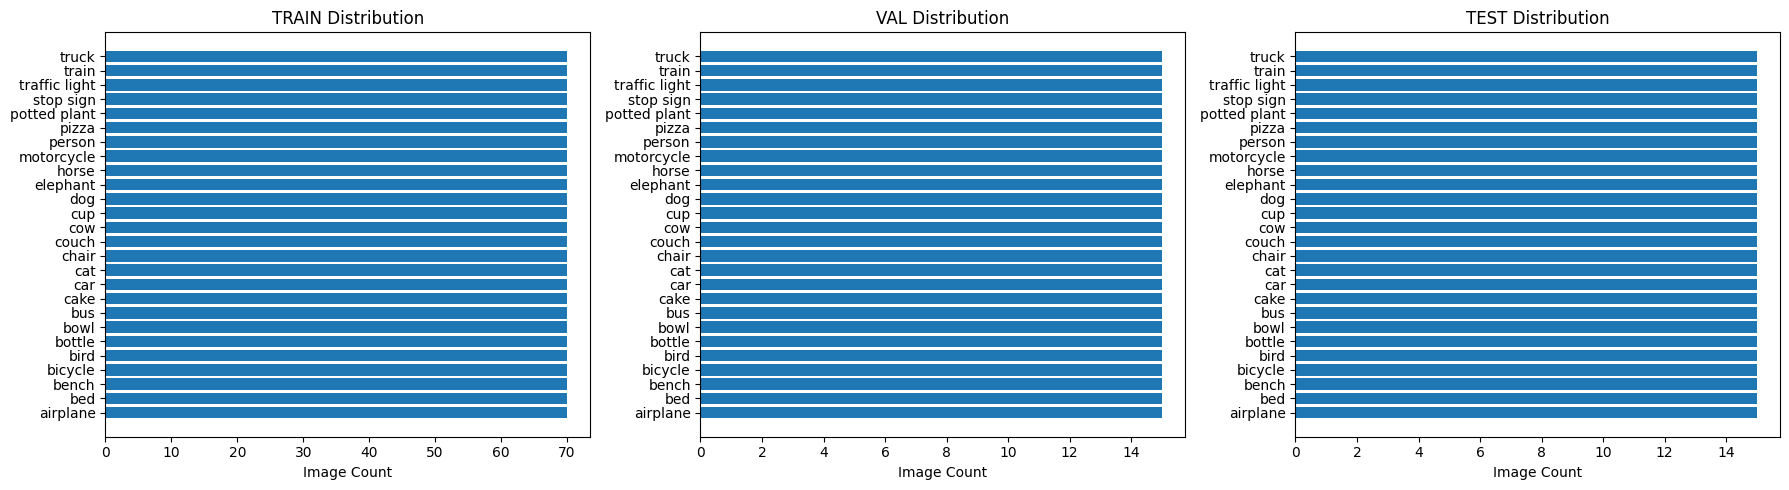

In [4]:
plt.figure(figsize=(18,5))  # one big figure

for idx, split in enumerate(splits):
    dataset_path = os.path.join(CLASSIFICATION_DIR, split)

    class_counts = {}

    for cls in os.listdir(dataset_path):
        class_path = os.path.join(dataset_path, cls)
        if os.path.isdir(class_path):
            class_counts[cls] = len(os.listdir(class_path))
            
        # Print class names and their image counts
    print(f"\n{split.upper()} dataset:")
    for class_name, image_count in class_counts.items():
        print(f"{class_name}: {image_count} images")        

    # Create subplot (1 row, 3 columns)
    plt.subplot(1, 3, idx + 1)

    plt.barh(list(class_counts.keys()), list(class_counts.values()))
    plt.title(f"{split.upper()} Distribution")
    plt.xlabel("Image Count")

plt.tight_layout()
plt.show()

**🔶 2. Image Characteristics (Size, Quality)**

CNN needs fixed size → decide resize strategy

In [5]:
dataset_path = os.path.join(CLASSIFICATION_DIR, split)

sizes = []

for cls in os.listdir(dataset_path):
    for img_name in os.listdir(os.path.join(dataset_path, cls))[:20]:
        img = Image.open(os.path.join(dataset_path, cls, img_name))
        sizes.append(img.size)

print("Sample sizes:", sizes[:5])


Sample sizes: [(224, 224), (224, 224), (224, 224), (224, 224), (224, 224)]


**🔶 3. Objects per Image (Detection)**


🎯 Why?


Understand complexity for YOLO

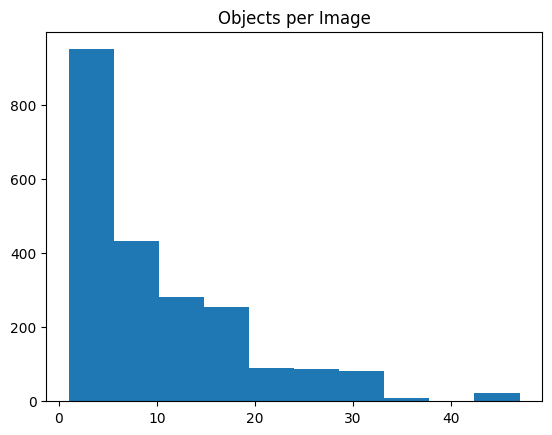

In [6]:
# label_dir = "smartvision_dataset/detection/labels"
DETECTION_IMG_DIR = os.path.join(BASE_DIR, "detection", "images")
DETECTION_LABEL_DIR = os.path.join(BASE_DIR, "detection", "labels")
counts = []

for file in os.listdir(DETECTION_LABEL_DIR):
    with open(os.path.join(DETECTION_LABEL_DIR, file)) as f:
        counts.append(len(f.readlines()))

plt.hist(counts)
plt.title("Objects per Image")
plt.show()

**🔶 4. Visualize Images + Bounding Boxes**

🎯 Why?

Verify annotations are correct

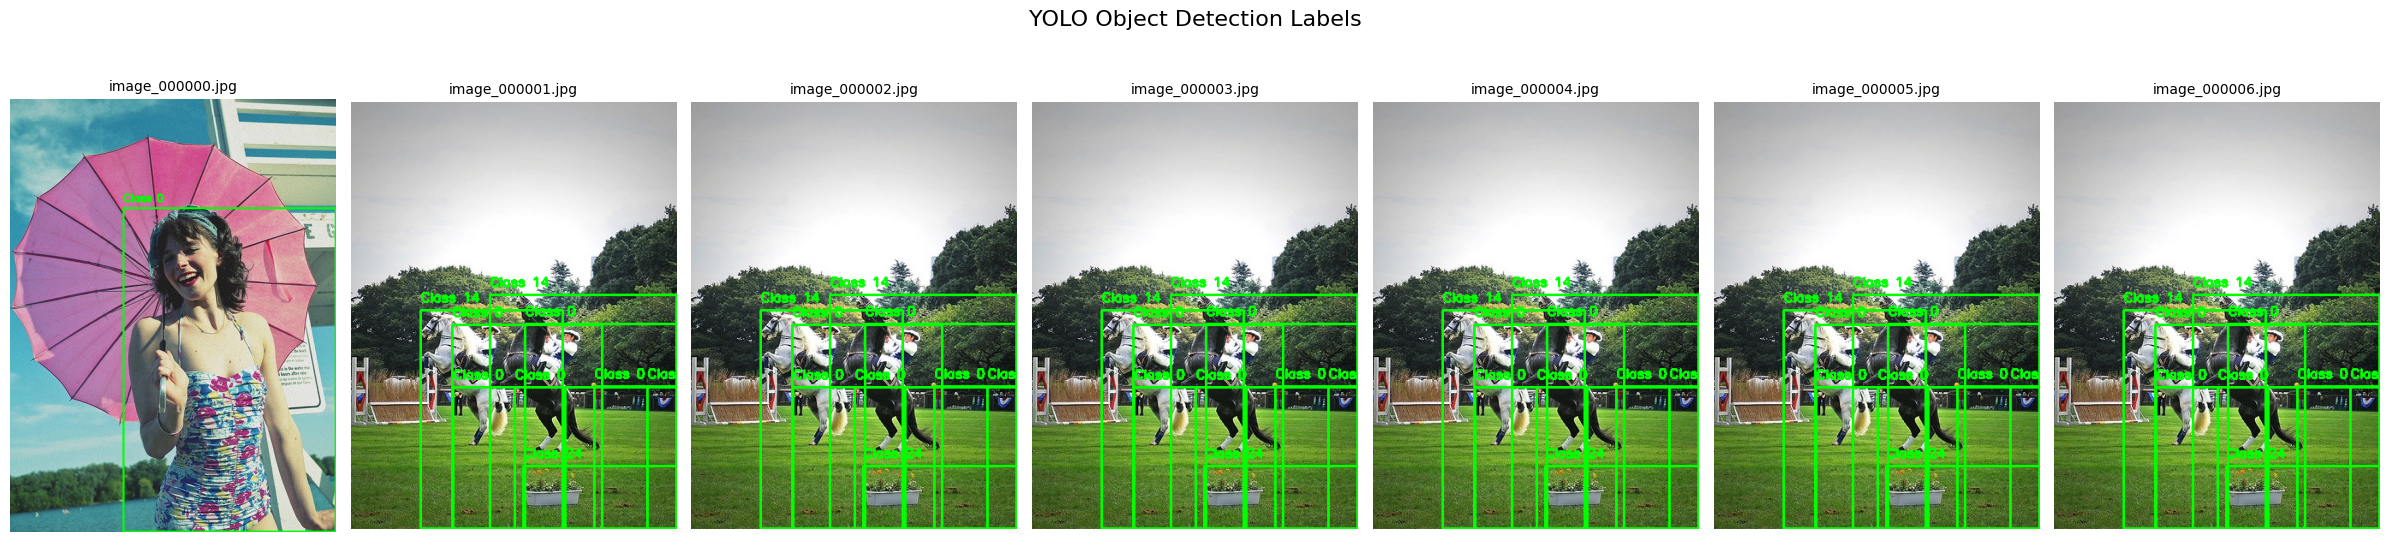

In [7]:
import os
import cv2
import matplotlib.pyplot as plt

# Image indices to visualize
indices_to_view = [0, 1, 2, 3, 4, 5, 6]

# Supported image extensions
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# Collect only image files and sort them for consistent ordering
all_files = sorted([
    file_name
    for file_name in os.listdir(DETECTION_IMG_DIR)
    if file_name.lower().endswith(valid_extensions)
])

# Create one subplot for each requested image
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(indices_to_view),
    figsize=(24, 6)
)

# Handle the case where only one index is supplied
if len(indices_to_view) == 1:
    axes = [axes]

for plot_position, image_index in enumerate(indices_to_view):
    ax = axes[plot_position]

    # Check whether the requested index exists
    if image_index >= len(all_files):
        ax.set_title(f"Index {image_index}\nNot available")
        ax.axis("off")
        print(f"Index {image_index} is outside the image list.")
        continue

    image_file = all_files[image_index]

    # Build image and label paths
    image_path = os.path.join(DETECTION_IMG_DIR, image_file)

    label_file = os.path.splitext(image_file)[0] + ".txt"
    label_path = os.path.join(DETECTION_LABEL_DIR, label_file)

    # Load image
    image = cv2.imread(image_path)

    if image is None:
        ax.set_title(f"{image_file}\nUnable to read")
        ax.axis("off")
        print(f"Unable to read image: {image_path}")
        continue

    image_height, image_width = image.shape[:2]

    # Read and draw YOLO labels
    if os.path.exists(label_path):
        with open(label_path, "r", encoding="utf-8") as label_data:
            for line_number, line in enumerate(label_data, start=1):
                parts = line.strip().split()

                # YOLO detection format:
                # class_id x_center y_center box_width box_height
                if len(parts) != 5:
                    print(
                        f"Invalid label in {label_file}, "
                        f"line {line_number}: {line.strip()}"
                    )
                    continue

                try:
                    class_id, x_center, y_center, box_width, box_height = map(
                        float, parts
                    )
                except ValueError:
                    print(
                        f"Non-numeric label in {label_file}, "
                        f"line {line_number}: {line.strip()}"
                    )
                    continue

                # Convert normalized YOLO values to pixel coordinates
                x1 = int((x_center - box_width / 2) * image_width)
                y1 = int((y_center - box_height / 2) * image_height)
                x2 = int((x_center + box_width / 2) * image_width)
                y2 = int((y_center + box_height / 2) * image_height)

                # Keep coordinates inside the image
                x1 = max(0, min(x1, image_width - 1))
                y1 = max(0, min(y1, image_height - 1))
                x2 = max(0, min(x2, image_width - 1))
                y2 = max(0, min(y2, image_height - 1))

                # Draw bounding box
                cv2.rectangle(
                    image,
                    (x1, y1),
                    (x2, y2),
                    (0, 255, 0),
                    2
                )

                # Create class text
                class_text = f"Class {int(class_id)}"

                # Prevent text from being drawn outside the image
                text_y = max(y1 - 10, 20)

                cv2.putText(
                    image,
                    class_text,
                    (x1, text_y),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 255, 0),
                    2
                )

    else:
        print(f"Label not found for {image_file}: {label_path}")

    # Convert OpenCV BGR image to RGB for Matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display image
    ax.imshow(image_rgb)
    ax.set_title(image_file, fontsize=10)
    ax.axis("off")

plt.suptitle("YOLO Object Detection Labels", fontsize=16)
plt.tight_layout()
plt.show()